In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [11]:
df = pd.read_csv("/home/mddo/stage/M2S4/output/FY/diploid_/diploid_0/df/HFI_NI_PROM_KNN.csv")
df["label"] = df["label"].replace(["ess"],1)
df["label"] = df["label"].replace(["non_ess"],0)
print(df)

print(df.corr())

hits_count  reads_count  hits_count_pro  ratio_hits_prom   orf_len  \
0       0.054913     0.039589        0.162162         2.000000  0.017981   
1       0.031792     0.040972        0.270270         1.428571  0.013895   
2       0.002890     0.000173        0.000000         0.400000  0.021251   
3       0.014451     0.040280        0.081081         0.600000  0.012056   
4       0.054913     0.017893        0.081081         1.000000  0.117899   
...          ...          ...             ...              ...       ...   
6349    0.089595     0.025240        0.000000         1.000000  0.079281   
6350    0.008671     0.000432        0.000000         0.690476  0.055442   
6351    0.000000     0.000000        0.000000         0.666667  0.017573   
6352    0.000000     0.000000        0.000000         0.666667  0.207601   
6353    0.000000     0.000000        0.000000         0.666667  0.029424   

      insertion_index        NI  NI_ratio       HFI  HFI_ratio        orf  \
0            0.0

label  number of genes
0  non_ess             5435
1      ess              919


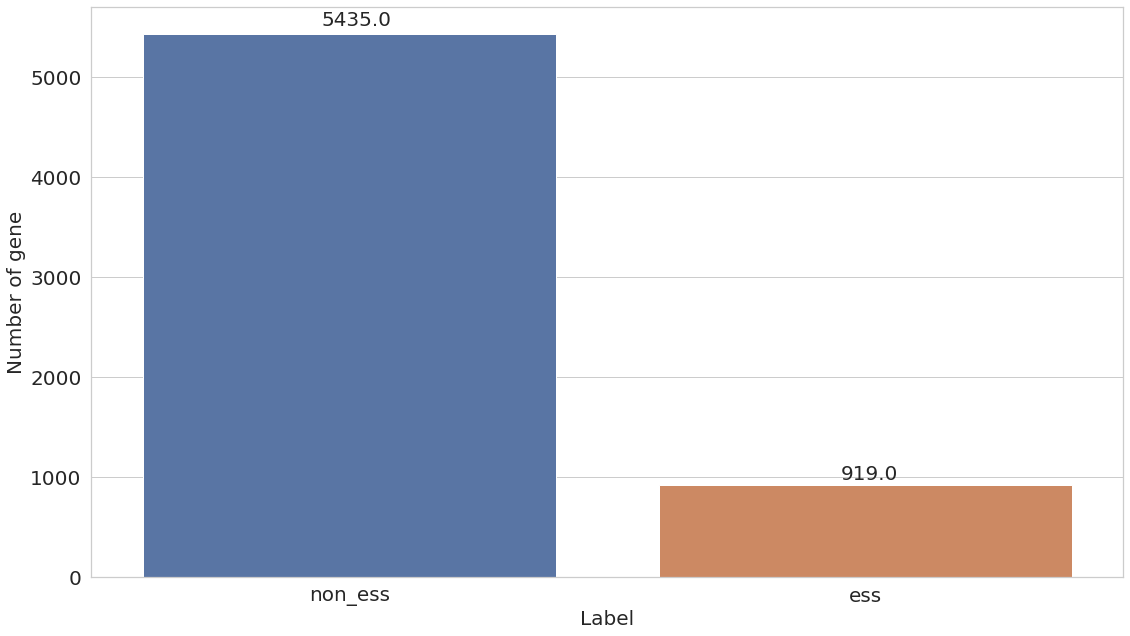

In [45]:
data_gene_count = df['label'].value_counts()
data_gene_count = pd.DataFrame(data_gene_count)
data_gene_count = data_gene_count.reset_index()
data_gene_count.columns = ["label","number of genes"]
print(data_gene_count)

sns.set(style="whitegrid")
#tips = sns.load_dataset("tips")
ax = sns.barplot(y = "number of genes", x = "label", data = data_gene_count, ci="sd")
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005),size=20, 
                xytext=(180, 2),  # 3 points vertical offset
                textcoords="offset points", va='bottom')
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(18.5, 10.5)
plt.xlabel("Label",size = 20)
plt.ylabel("Number of gene",size = 20)
plt.xticks(size = 20)
plt.yticks(size = 20)
fig.savefig('test2png.png', dpi=100)



In [46]:
X = df.drop(columns = ["label","orf"], axis = 1)
y = df['label']
print(X)
print(y)



hits_count_pro   orf_len  insertion_index  reads_by_len        NI  \
0           0.162162  0.017981         0.060510      1.458599  2.806597   
1           0.270270  0.013895         0.043307      1.866142  2.021966   
2           0.000000  0.021251         0.002762      0.005525  0.133049   
3           0.081081  0.012056         0.022026      2.052863  1.095846   
4           0.081081  0.117899         0.010668      0.116227  0.646895   
...              ...       ...              ...           ...       ...   
6349        0.000000  0.079281         0.025535      0.240527  0.980966   
6350        0.000000  0.055442         0.003472      0.005787  0.156202   
6351        0.000000  0.017573         0.000000      0.000000  0.000000   
6352        0.000000  0.207601         0.000000      0.000000  0.000000   
6353        0.000000  0.029424         0.000000      0.000000  0.000000   

           HFI  
0     0.168790  
1     0.574803  
2     0.549724  
3     0.845815  
4     0.253790  
...

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [48]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=10)

In [49]:
x = random_forest.fit(X_train, y_train)
print(x)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=10, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=1000,
                       n_jobs=None, oob_score=False, random_state=10, verbose=0,
                       warm_start=False)


In [50]:
from sklearn.metrics import accuracy_score
y_predict = random_forest.predict(X_test)
accuracy_score(y_test, y_predict)

0.8829452485840151

Feature ranking:
1. feature 2 (0.232276)
2. feature 3 (0.202142)
3. feature 1 (0.182103)
4. feature 4 (0.164079)
5. feature 5 (0.110376)
6. feature 0 (0.109023)


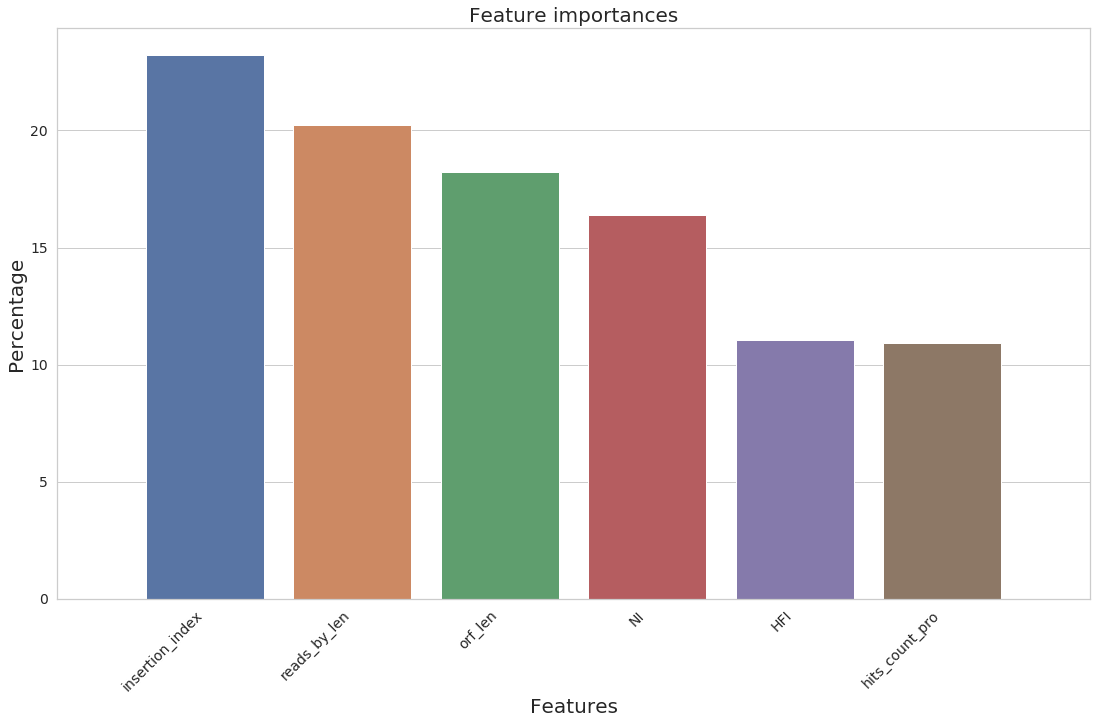

In [51]:
importances = random_forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in random_forest.estimators_],
             axis=0)
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")

col_feats = []
for f in range(X.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))
    col_feats.append([X.columns[indices[f]],importances[indices[f]]*100])

ft_importances = pd.DataFrame(col_feats)
ft_importances.columns = ["Feature","percentage"]

# Plot the feature importances of the forest
plt.figure()
plt.title("Feature importances", size = 20)
sns.barplot(x = "Feature", y = "percentage", data = ft_importances)
#plt.bar(range(X.shape[1]), importances[indices],
#       color="r", yerr=std[indices], align="center")
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xlim([-1, X.shape[1]])
plt.xlabel("Features", size = 20)
plt.ylabel("Percentage", size = 20)
plt.xticks(rotation=45, ha='right')
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(18.5, 10.5)
plt.show()

In [52]:
test_df = pd.read_csv("/home/mddo/stage/M2S4/output/BHH/diploid_/diploid_0/df/normal_KNN.csv")

In [53]:
X_test = test_df.drop(columns = ["label","orf"], axis = 1)
y_test = test_df['label']

In [54]:
y_predict = random_forest.predict(X_test)
accuracy_score(y_test, y_predict)

ValueError: Number of features of the model must match the input. Model n_features is 6 and input n_features is 8 

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
test_df["predictions"] = pd.DataFrame(y_predict)

precision_recall_fscore = precision_recall_fscore_support(test_df["label"], test_df["predictions"],average = "binary", pos_label="ess")
precision = precision_recall_fscore[0]
recall = precision_recall_fscore[1]
fscore = precision_recall_fscore[2]
print(precision)
print(recall)
print(fscore)

In [ ]:
df_test.to_csv("/home/mddo/stage/M2S4/output/CCD/diploid_/diploid_0/df/normal_raw_predicted.csv", index=False)